<a href="https://colab.research.google.com/github/GideonBature/d2lai/blob/main/chapter_preliminaries/autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automatic Differentiation
:label:`sec_autograd`

Recall from :numref:`sec_calculus`
that calculating derivatives is the crucial step
in all the optimization algorithms
that we will use to train deep networks.
While the calculations are straightforward,
working them out by hand can be tedious and error-prone,
and these issues only grow
as our models become more complex.

Fortunately all modern deep learning frameworks
take this work off our plates
by offering *automatic differentiation*
(often shortened to *autograd*).
As we pass data through each successive function,
the framework builds a *computational graph*
that tracks how each value depends on others.
To calculate derivatives,
automatic differentiation
works backwards through this graph
applying the chain rule.
The computational algorithm for applying the chain rule
in this fashion is called *backpropagation*.

While autograd libraries have become
a hot concern over the past decade,
they have a long history.
In fact the earliest references to autograd
date back over half of a century :cite:`Wengert.1964`.
The core ideas behind modern backpropagation
date to a PhD thesis from 1980 :cite:`Speelpenning.1980`
and were further developed in the late 1980s :cite:`Griewank.1989`.
While backpropagation has become the default method
for computing gradients, it is not the only option.
For instance, the Julia programming language employs
forward propagation :cite:`Revels.Lubin.Papamarkou.2016`.
Before exploring methods,
let's first master the autograd package.


In [1]:
import torch

## A Simple Function

Let's assume that we are interested
in (**differentiating the function
$y = 2\mathbf{x}^{\top}\mathbf{x}$
with respect to the column vector $\mathbf{x}$.**)
To start, we assign `x` an initial value.


In [7]:
x = torch.arange(5.0)
x

tensor([0., 1., 2., 3., 4.])

[**Before we calculate the gradient
of $y$ with respect to $\mathbf{x}$,
we need a place to store it.**]
In general, we avoid allocating new memory
every time we take a derivative
because deep learning requires
successively computing derivatives
with respect to the same parameters
a great many times,
and we might risk running out of memory.
Note that the gradient of a scalar-valued function
with respect to a vector $\mathbf{x}$
is vector-valued with
the same shape as $\mathbf{x}$.


In [8]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad  # The gradient is None by default

(**We now calculate our function of `x` and assign the result to `y`.**)


In [9]:
y = 2 * torch.dot(x, x)
# print(f"Here:, {torch.dot(x, x)}")
y

tensor(60., grad_fn=<MulBackward0>)

[**We can now take the gradient of `y`
with respect to `x`**] by calling
its `backward` method.
Next, we can access the gradient
via `x`'s `grad` attribute.


In [10]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12., 16.])

(**We already know that the gradient of the function $y = 2\mathbf{x}^{\top}\mathbf{x}$
with respect to $\mathbf{x}$ should be $4\mathbf{x}$.**)
We can now verify that the automatic gradient computation
and the expected result are identical.


In [11]:
x.grad == 4 * x

tensor([True, True, True, True, True])

[**Now let's calculate
another function of `x`
and take its gradient.**]
Note that PyTorch does not automatically
reset the gradient buffer
when we record a new gradient.
Instead, the new gradient
is added to the already-stored gradient.
This behavior comes in handy
when we want to optimize the sum
of multiple objective functions.
To reset the gradient buffer,
we can call `x.grad.zero_()` as follows:


In [12]:
x.grad.zero_()  # Reset the gradient
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1., 1.])

## Backward for Non-Scalar Variables

When `y` is a vector,
the most natural representation
of the derivative of  `y`
with respect to a vector `x`
is a matrix called the *Jacobian*
that contains the partial derivatives
of each component of `y`
with respect to each component of `x`.
Likewise, for higher-order `y` and `x`,
the result of differentiation could be an even higher-order tensor.

While Jacobians do show up in some
advanced machine learning techniques,
more commonly we want to sum up
the gradients of each component of `y`
with respect to the full vector `x`,
yielding a vector of the same shape as `x`.
For example, we often have a vector
representing the value of our loss function
calculated separately for each example among
a *batch* of training examples.
Here, we just want to (**sum up the gradients
computed individually for each example**).


Because deep learning frameworks vary
in how they interpret gradients of
non-scalar tensors,
PyTorch takes some steps to avoid confusion.
Invoking `backward` on a non-scalar elicits an error
unless we tell PyTorch how to reduce the object to a scalar.
More formally, we need to provide some vector $\mathbf{v}$
such that `backward` will compute
$\mathbf{v}^\top \partial_{\mathbf{x}} \mathbf{y}$
rather than $\partial_{\mathbf{x}} \mathbf{y}$.
This next part may be confusing,
but for reasons that will become clear later,
this argument (representing $\mathbf{v}$) is named `gradient`.
For a more detailed description, see Yang Zhang's
[Medium post](https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29).


In [13]:
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
x.grad

tensor([0., 2., 4., 6., 8.])

## Detaching Computation

Sometimes, we wish to [**move some calculations
outside of the recorded computational graph.**]
For example, say that we use the input
to create some auxiliary intermediate terms
for which we do not want to compute a gradient.
In this case, we need to *detach*
the respective computational graph
from the final result.
The following toy example makes this clearer:
suppose we have `z = x * y` and `y = x * x`
but we want to focus on the *direct* influence of `x` on `z`
rather than the influence conveyed via `y`.
In this case, we can create a new variable `u`
that takes the same value as `y`
but whose *provenance* (how it was created)
has been wiped out.
Thus `u` has no ancestors in the graph
and gradients do not flow through `u` to `x`.
For example, taking the gradient of `z = x * u`
will yield the result `u`,
(not `3 * x * x` as you might have
expected since `z = x * x * x`).


In [17]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True, True])

Note that while this procedure
detaches `y`'s ancestors
from the graph leading to `z`,
the computational graph leading to `y`
persists and thus we can calculate
the gradient of `y` with respect to `x`.


In [18]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True, True])

## Gradients and Python Control Flow

So far we reviewed cases where the path from input to output
was well defined via a function such as `z = x * x * x`.
Programming offers us a lot more freedom in how we compute results.
For instance, we can make them depend on auxiliary variables
or condition choices on intermediate results.
One benefit of using automatic differentiation
is that [**even if**] building the computational graph of
(**a function required passing through a maze of Python control flow**)
(e.g., conditionals, loops, and arbitrary function calls),
(**we can still calculate the gradient of the resulting variable.**)
To illustrate this, consider the following code snippet where
the number of iterations of the `while` loop
and the evaluation of the `if` statement
both depend on the value of the input `a`.


In [19]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

Below, we call this function, passing in a random value, as input.
Since the input is a random variable,
we do not know what form
the computational graph will take.
However, whenever we execute `f(a)`
on a specific input, we realize
a specific computational graph
and can subsequently run `backward`.


In [20]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

Even though our function `f` is, for demonstration purposes, a bit contrived,
its dependence on the input is quite simple:
it is a *linear* function of `a`
with piecewise defined scale.
As such, `f(a) / a` is a vector of constant entries
and, moreover, `f(a) / a` needs to match
the gradient of `f(a)` with respect to `a`.


In [21]:
a.grad == d / a

tensor(True)

Dynamic control flow is very common in deep learning.
For instance, when processing text, the computational graph
depends on the length of the input.
In these cases, automatic differentiation
becomes vital for statistical modeling
since it is impossible to compute the gradient *a priori*.

## Discussion

You have now gotten a taste of the power of automatic differentiation.
The development of libraries for calculating derivatives
both automatically and efficiently
has been a massive productivity booster
for deep learning practitioners,
liberating them so they can focus on less menial.
Moreover, autograd lets us design massive models
for which pen and paper gradient computations
would be prohibitively time consuming.
Interestingly, while we use autograd to *optimize* models
(in a statistical sense)
the *optimization* of autograd libraries themselves
(in a computational sense)
is a rich subject
of vital interest to framework designers.
Here, tools from compilers and graph manipulation
are leveraged to compute results
in the most expedient and memory-efficient manner.

For now, try to remember these basics: (i) attach gradients to those variables with respect to which we desire derivatives; (ii) record the computation of the target value; (iii) execute the backpropagation function; and  (iv) access the resulting gradient.


## Exercises

1. Why is the second derivative much more expensive to compute than the first derivative?
1. After running the function for backpropagation, immediately run it again and see what happens. Investigate.
1. In the control flow example where we calculate the derivative of `d` with respect to `a`, what would happen if we changed the variable `a` to a random vector or a matrix? At this point, the result of the calculation `f(a)` is no longer a scalar. What happens to the result? How do we analyze this?
1. Let $f(x) = \sin(x)$. Plot the graph of $f$ and of its derivative $f'$. Do not exploit the fact that $f'(x) = \cos(x)$ but rather use automatic differentiation to get the result.
1. Let $f(x) = ((\log x^2) \cdot \sin x) + x^{-1}$. Write out a dependency graph tracing results from $x$ to $f(x)$.
1. Use the chain rule to compute the derivative $\frac{df}{dx}$ of the aforementioned function, placing each term on the dependency graph that you constructed previously.
1. Given the graph and the intermediate derivative results, you have a number of options when computing the gradient. Evaluate the result once starting from $x$ to $f$ and once from $f$ tracing back to $x$. The path from $x$ to $f$ is commonly known as *forward differentiation*, whereas the path from $f$ to $x$ is known as backward differentiation.
1. When might you want to use forward, and when backward, differentiation? Hint: consider the amount of intermediate data needed, the ability to parallelize steps, and the size of matrices and vectors involved.


[Discussions](https://discuss.d2l.ai/t/35)


## Solution

Let's work through the exercises in order.
As in the lesson, we first explain the computation
and then use PyTorch to examine the result.
Each example starts with fresh tensors so that gradients
from earlier examples do not accumulate unexpectedly.

### 1. Computing Second Derivatives

The first derivative tells us how a function changes,
whereas the second derivative tells us how its first derivative changes.
To compute a second derivative with automatic differentiation,
we must therefore record the operations used to compute the first derivative.
In PyTorch, we request this additional graph with `create_graph=True`.
Without it, the computed gradient normally has no graph
through which we can differentiate again.

This extra graph requires memory and another differentiation pass.
For a scalar function of $n$ inputs, the first derivative has $n$ entries,
but the full second derivative, called the *Hessian*, has $n^2$ entries.
Computing and storing all of these entries can be much more expensive.
However, a second derivative of a scalar-input function is not necessarily
much more expensive, and a Hessian-vector product can avoid forming the full Hessian.

For example, if $y = x^3$, then $dy/dx = 3x^2$
and $d^2y/dx^2 = 6x$.
Let's verify both derivatives at $x = 2$.

In [22]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3
first_derivative, = torch.autograd.grad(y, x, create_graph=True)
second_derivative, = torch.autograd.grad(first_derivative, x)
print("First derivative:", first_derivative.item())
print("Second derivative:", second_derivative.item())

First derivative: 12.0
Second derivative: 12.0


### 2. Calling Backpropagation Twice

By default, PyTorch frees saved intermediate values
once `backward()` has used them.
Calling `backward()` again on the same result can therefore raise a `RuntimeError`
because those values are no longer available.
Let's observe this with $y = x^2$.
We catch the error so that the remaining notebook cells can still run.

In [26]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2
y.backward()
print("After the first call:", x.grad)
try:
    y.backward()
except RuntimeError as error:
    print("Second call:", str(error).split(". ")[0])

After the first call: tensor(4.)
Second call: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed)


If we need to reuse this graph, we can pass `retain_graph=True`
to the first call. Notice that retaining a graph
and clearing the gradient buffer are separate operations:
`backward()` still adds each new gradient to `x.grad`.
For $x = 2$, each call contributes $2x = 4$,
so two calls without resetting the buffer produce $8$.

Alternatively, we can recompute `y` to build a fresh graph.
Also, repeated backpropagation does not fail for every possible graph:
some simple operations do not need saved intermediate values.
The error depends on which operations the graph contains.

In [29]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2
y.backward(retain_graph=True)
print("After the first call:", x.grad.clone())
y.backward(retain_graph=True)
print("After the second call (accumulated):", x.grad.clone())
y.backward()
print("After the Third call (accumulated):", x.grad.clone())

x.grad.zero_()
y = x ** 2  # Recompute the result to build a fresh graph
y.backward()
print("After resetting and recomputing:", x.grad)

After the first call: tensor(4.)
After the second call (accumulated): tensor(8.)
After the Third call (accumulated): tensor(12.)
After resetting and recomputing: tensor(4.)


### 3. Using a Vector or Matrix in the Control Flow Example

The function `f` above also accepts vectors and matrices.
Both `b.norm()` and `b.sum()` return scalars,
so the loop condition and branch condition still work.
The output `d = f(a)` has the same shape as `a`.
However, `d.backward()` without a `gradient` argument fails
when `d` has more than one element.
We must specify which scalar combination of the output we want to differentiate.

On a fixed execution path, the loop and branch multiply every element
by the same scale $s$, giving $\mathbf{d} = s\mathbf{a}$.
If we flatten the input and output into vectors,
the Jacobian is $J = sI$.
Consequently, `d.sum().backward()` gives a gradient of $s$
for every input entry. More generally, passing an output-shaped tensor
$\mathbf{v}$ to `backward` computes $J^\top\mathbf{v} = s\mathbf{v}$.

Let's try both a vector and a matrix using a fixed random seed.
We reuse the lesson's definition of `f`.

In [31]:
generator = torch.Generator().manual_seed(7)
for shape in [(3,), (2, 3)]:
    a = torch.randn(shape, generator=generator, requires_grad=True)
    d = f(a)
    try:
        d.backward()
    except RuntimeError as error:
        print(f"Shape {shape}, direct backward:", str(error))
    d.sum().backward()
    scale = (d.detach().flatten()[0] / a.detach().flatten()[0]).item()
    print("Output shape:", tuple(d.shape))
    print("Gradient of the sum:", a.grad)
    print("Matches the scale:", torch.allclose(a.grad, torch.full_like(a, scale)))

Shape (3,), direct backward: grad can be implicitly created only for scalar outputs
Output shape: (3,)
Gradient of the sum: tensor([1024., 1024., 1024.])
Matches the scale: True
Shape (2, 3), direct backward: grad can be implicitly created only for scalar outputs
Output shape: (2, 3)
Gradient of the sum: tensor([[512., 512., 512.],
        [512., 512., 512.]])
Matches the scale: True


The scale is constant only within a region where the same loop count
and branch are selected. Autograd differentiates the operations
on the executed path; it does not differentiate Python's decisions.
At a boundary where that path changes, the function may be discontinuous
and the ordinary derivative may not exist.
Also, an all-zero input makes the original loop run forever,
because doubling zero can never make its norm reach $1000$.

### 4. Plotting a Function and Its Automatic Derivative

Let's sample $f(x) = \sin(x)$ at points between $-2\pi$ and $2\pi$.
Each output $y_i$ depends only on its corresponding input $x_i$.
Therefore, differentiating `y.sum()` gives the individual derivative
at every sampled point, without explicitly constructing a Jacobian.

We obtain the derivative entirely through `backward()`.
Before plotting, we detach the tensors so that plotting does not
participate in the computational graph.

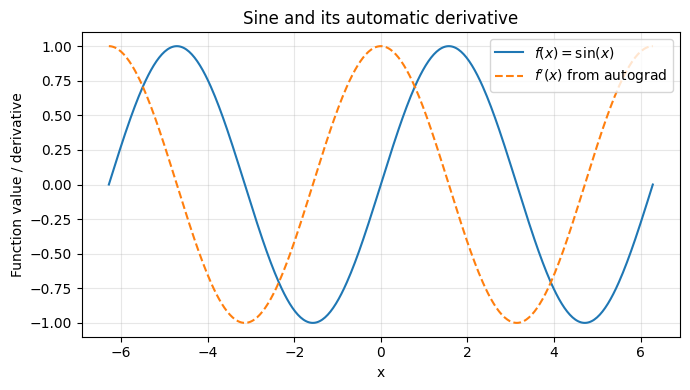

In [36]:
import matplotlib.pyplot as plt

x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 401, requires_grad=True)
y = torch.sin(x)
y.sum().backward()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x.detach().numpy(), y.detach().numpy(), label=r"$f(x) = \sin(x)$")
ax.plot(x.detach().numpy(), x.grad.numpy(), "--", label=r"$f'(x)$ from autograd")
ax.set_xlabel("x")
ax.set_ylabel("Function value / derivative")
ax.set_title("Sine and its automatic derivative")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

### 5. Constructing the Dependency Graph

For the remaining exercises, consider

$$f(x) = \log(x^2)\sin(x) + x^{-1}, \qquad x \ne 0.$$

Here, $\log(x^2)$ means the logarithm of $x^2$.
Let's give each intermediate result a name:

$$u = x^2, \quad v = \log(u), \quad w = \sin(x),
\quad p = vw, \quad q = x^{-1}, \quad f = p + q.$$

The dependency graph below shows the three paths
by which the input influences the output.
The two copies of `x` at the bottom refer to the same input node.

```text
x ──→ u = x² ──→ v = log(u) ──┐
                              ├──→ p = v·w ──┐
x ─────────────→ w = sin(x) ──┘               ├──→ f = p + q
x ───────────────────────→ q = 1/x ─────────┘
```

For every nonzero real $x$, $u = x^2$ is positive,
so its logarithm is defined, including when $x$ is negative.
At $x = 0$, both the logarithm and the reciprocal are undefined.

### 6. Applying the Chain Rule on the Graph

Each edge carries a *local derivative*: the derivative of its destination
with respect to its source, holding other inputs to that operation fixed.
Let's place those derivatives on the same dependency graph.

```text
x ──[2x]──→ u ──[1/u]──→ v ──[w]──┐
                                    ├──→ p ──[1]──┐
x ─────────[cos(x)]──────→ w ──[v]──┘             ├──→ f
x ───────────────[-1/x²]─────────→ q ──[1]────────┘
```

We multiply local derivatives along each path from $x$ to $f$
and add the contributions of all paths.
This gives

$$\frac{df}{dx}
= (2x)\frac{1}{u}w + \cos(x)v - \frac{1}{x^2}
= \frac{2\sin(x)}{x} + \log(x^2)\cos(x) - \frac{1}{x^2}.$$

The first two terms are the two contributions from differentiating
$v w$ with the product rule; the last comes from the reciprocal.
Let's compare this expression with autograd at several nonzero inputs.

In [37]:
x = torch.tensor([-2.0, -0.5, 0.5, 2.0], dtype=torch.float64, requires_grad=True)
y = torch.log(x ** 2) * torch.sin(x) + x.reciprocal()
y.sum().backward()
expected = (2 * torch.sin(x) / x + torch.log(x ** 2) * torch.cos(x)
            - x.reciprocal() ** 2)
print("Autograd:", x.grad)
print("Chain rule:", expected.detach())
print("Results agree:", torch.allclose(x.grad, expected))

Autograd: tensor([ 0.0824, -3.2989, -3.2989,  0.0824], dtype=torch.float64)
Chain rule: tensor([ 0.0824, -3.2989, -3.2989,  0.0824], dtype=torch.float64)
Results agree: True


### 7. Evaluating Forward and Backward Differentiation

Both methods use the same local derivatives from our graph,
but propagate them in different directions.
Let's evaluate the function and derivative at $x = 2$.

In *forward differentiation*, each intermediate carries a tangent
$\dot{z} = dz/dx$ alongside its value.
We start with $\dot{x} = 1$ and propagate toward $f$:

$$\begin{aligned}
\dot{u} &= 2x\dot{x}, & \dot{v} &= \dot{u}/u, \\
\dot{w} &= \cos(x)\dot{x}, & \dot{p} &= w\dot{v} + v\dot{w}, \\
\dot{q} &= -\dot{x}/x^2, & \dot{f} &= \dot{p} + \dot{q}.
\end{aligned}$$

Let's implement these updates explicitly to see how derivatives
travel through the graph.

In [39]:
import math

x_value = 2.0
u = x_value ** 2
v = math.log(u)
w = math.sin(x_value)
p = v * w
q = 1 / x_value
f_value = p + q

x_dot = 1.0
u_dot = 2 * x_value * x_dot
v_dot = u_dot / u
w_dot = math.cos(x_value) * x_dot
p_dot = w * v_dot + v * w_dot
q_dot = -x_dot / x_value ** 2
f_dot = p_dot + q_dot
print("Function value:", f_value)
print("Forward derivative:", f_dot)

Function value: 1.7605538953892688
Forward derivative: 0.08239541392249738


In *backward differentiation*, we first evaluate the function
and keep the intermediate values needed by the local derivatives.
Then we propagate adjoints $\bar{z} = \partial f/\partial z$
from the output back toward the input.
Starting with $\bar{f} = 1$, we obtain

$$\bar{p} = 1, \quad \bar{q} = 1, \quad
\bar{v} = w\bar{p}, \quad \bar{w} = v\bar{p}, \quad
\bar{u} = \bar{v}/u.$$

The input has three outgoing paths.
We must add all three contributions to its adjoint:

$$\bar{x} = 2x\bar{u} + \cos(x)\bar{w} - \bar{q}/x^2.$$

This addition at a shared input is the graph-level reason
why gradients from multiple paths must accumulate.

In [40]:
f_bar = 1.0
p_bar = f_bar
q_bar = f_bar
v_bar = w * p_bar
w_bar = v * p_bar
u_bar = v_bar / u
x_bar = 2 * x_value * u_bar + math.cos(x_value) * w_bar - q_bar / x_value ** 2

x = torch.tensor(x_value, dtype=torch.float64, requires_grad=True)
y = torch.log(x ** 2) * torch.sin(x) + x.reciprocal()
y.backward()
print("Backward derivative:", x_bar)
print("Autograd derivative:", x.grad.item())
print("All three agree:", math.isclose(f_dot, x_bar)
      and math.isclose(x_bar, x.grad.item()))

Backward derivative: 0.08239541392249738
Autograd derivative: 0.08239541392249738
All three agree: True


### 8. Choosing Forward or Backward Differentiation

Suppose a function maps $n$ inputs to $m$ outputs.
Its Jacobian $J$ has shape $m \times n$.
Forward mode propagates an input direction $\mathbf{v}$
and computes $J\mathbf{v}$ in one pass.
Reverse (backward) mode starts with an output direction $\mathbf{w}$
and computes $J^\top\mathbf{w}$ in one reverse pass,
after the function has been evaluated.

If we need the full Jacobian, forward mode generally needs
$n$ input directions, while reverse mode needs $m$ output directions.
This leads to the following practical choices:

| Situation | Typical choice | Reason |
| --- | --- | --- |
| Few inputs, many outputs | Forward mode | Few input directions produce all Jacobian columns. |
| Many inputs, few outputs | Reverse mode | Few output directions produce all Jacobian rows. |
| A scalar training loss with many parameters | Reverse mode | One reverse pass computes the gradient of every parameter. |
| Only a directional derivative $J\mathbf{v}$ is needed | Forward mode | One seeded pass avoids constructing the full Jacobian. |
| Only $J^\top\mathbf{w}$ is needed | Reverse mode | One reverse pass computes the required weighted gradient. |

Memory also matters. Forward mode can propagate values and tangents
as it evaluates operations, often without saving the entire execution history.
Reverse mode usually saves intermediate values for its later backward pass,
which can require substantial memory for a large model.
Checkpointing trades extra computation for reduced storage.

Independent directions can be batched or parallelized in either mode,
and independent branches of the graph can also run in parallel.
However, batching many directions increases the intermediate tensor sizes,
and dependencies between operations still constrain execution order.
Both modes can become expensive if we explicitly request a large full Jacobian;
often a Jacobian-vector or vector-Jacobian product is all we need.

For our scalar-input, scalar-output function in Exercises 5–7,
each mode needs only one direction, so neither has an advantage
based on input and output dimensions alone.